# 삼양사 식품부문 매출 × 경제지표 상관관계 분석

DART 공시 원문(`data/dart_xml/`)에서 삼양사 식품부문 매출액을 직접 파싱해서 추출하고,
`Food_Company_Sales` 대시보드가 이미 수집해 둔 32개 경제지표(PostgreSQL/Neon)와 대조한다.

구성:
1. DART 공시에서 식품부문 매출 추출
2. 누적치를 분기 단위로 역산
3. DB에서 관련 경제지표 로드
4. 레벨 / 변화율 / 시차(lag) 세 가지 각도로 상관관계 계산

> **주의**: 표본이 15~18개 분기로 작다. 상관계수는 확정된 관계가 아니라 참고용 신호로 해석할 것.

## 0. 환경 설정

In [1]:
import re
import sys
from pathlib import Path
from datetime import date

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import dart_parser  # 이 노트북과 같은 폴더의 dart_parser.py

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트 (다른 OS라면 폰트명 교체)

In [2]:
DART_DIR = Path("data/dart_xml")
TARGET_COMPANIES = {"(주)삼양사", "삼양사"}  # 계열사 중 삼양사 표기 변형

# 지표 DB(DATABASE_URL)는 Food_Company_Sales/dashboard/backend/.env 에 있다
DASHBOARD_ENV = Path(r"C:\Users\alswn\projects\Food_Company_Sales\dashboard\backend\.env")
load_dotenv(DASHBOARD_ENV)

True

## 1. DART 공시에서 삼양사 식품부문 매출 추출

사업/반기/분기보고서의 "나. 사업부문별 재무정보" 표에서 `식품 | 매출액 | ...` 행만 정규식으로 뽑는다.
이 값은 **그 보고서의 회계연도 시작일부터 보고 기준일까지의 누적 매출**이다
(분기보고서 Q1=3개월, 반기보고서=6개월, 9개월보고서=9개월, 사업보고서=12개월 누적).

In [3]:
FOOD_ROW_RE = re.compile(r"식품\s*\|\s*매출액:?\s*\|\s*([\d,]+)")


def parse_period(fp: str):
    m = re.match(r"(\d{4})\.(\d{2})\.(\d{2})~(\d{4})\.(\d{2})\.(\d{2})", fp)
    if not m:
        return None
    y1, mo1, d1, y2, mo2, d2 = map(int, m.groups())
    return date(y1, mo1, d1), date(y2, mo2, d2)


records, failed = [], []
for f in sorted(DART_DIR.glob("*.xml")):
    docs = dart_parser.parse_dart_xml(f)
    if not docs or docs[0].metadata["company"] not in TARGET_COMPANIES:
        continue
    doc_type = docs[0].metadata["doc_type"]
    period = parse_period(docs[0].metadata["fiscal_period"])
    if period is None:
        failed.append((f.name, "기간 파싱 실패"))
        continue
    found = None
    for d in docs:
        m = FOOD_ROW_RE.search(d.page_content)
        if m:
            found = int(m.group(1).replace(",", ""))
            break
    if found is None:
        failed.append((f.name, "식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)"))
        continue
    records.append((f.name, doc_type, period[0], period[1], found))

print(f"성공 {len(records)}건 / 실패 {len(failed)}건")
for fname, reason in failed:
    print(" -", fname, ":", reason)

성공 23건 / 실패 5건
 - 20200814002597.xml : 식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)
 - 20201116001322.xml : 식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)
 - 20210317001085.xml : 식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)
 - 20210517000924.xml : 식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)
 - 20210817001681.xml : 식품 매출 행 없음 (표 형식이 다름 — 2020~2021 상반기 공시 일부)


In [4]:
# 같은 (문서유형, 기간) 조합이 여러 건이면(정정신고 등) 접수번호가 큰(=나중 제출) 파일만 남긴다
best = {}
for fname, doc_type, pfrom, pto, rev in records:
    key = (doc_type, pfrom, pto)
    if key not in best or fname > best[key][0]:
        best[key] = (fname, doc_type, pfrom, pto, rev)

cum_df = pd.DataFrame(
    sorted(best.values(), key=lambda r: (r[3], r[2])),
    columns=["file", "doc_type", "period_from", "period_to", "food_revenue_cum"],
)
cum_df

,file,doc_type,period_from,period_to,food_revenue_cum
0,20211115001283.xml,분기보고서,2021-01-01,2021-09-30,898414
1,20220812000103.xml,사업보고서,2021-01-01,2021-12-31,1238777
2,20220516002151.xml,분기보고서,2022-01-01,2022-03-31,328648
3,20220816001838.xml,반기보고서,2022-01-01,2022-06-30,716496
4,20221114002256.xml,분기보고서,2022-01-01,2022-09-30,1111293
5,20230315001060.xml,사업보고서,2022-01-01,2022-12-31,1491800
6,20230515001942.xml,분기보고서,2023-01-01,2023-03-31,383173
7,20230811001664.xml,반기보고서,2023-01-01,2023-06-30,801087
8,20231114002455.xml,분기보고서,2023-01-01,2023-09-30,1192224
9,20240325000879.xml,사업보고서,2023-01-01,2023-12-31,1595331


## 2. 누적 매출을 분기 단위로 역산

같은 회계연도 안에서 연속된 보고서의 누적치를 차분하면 그 구간만의 매출이 나온다
(Q2 = 반기누적 − Q1, Q3 = 9개월누적 − 반기누적, Q4 = 연간누적 − 9개월누적).

**주의**: 그 해의 첫 보고서가 원래 1분기(약 90일)보다 훨씬 긴 기간을 다루고 있으면
(= 앞선 분기 보고서가 파싱에서 빠진 경우), 그 값은 여러 분기가 뭉친 것이라 단일 구간
매출로 쓰면 이상치가 된다. 이 경우는 구간으로 만들지 않고 기준점만 갱신한다.

In [5]:
quarter_records = []
by_year = {}
for _, row in cum_df.iterrows():
    by_year.setdefault(row.period_from.year, []).append(row)

for year, rows in sorted(by_year.items()):
    rows = sorted(rows, key=lambda r: r.period_to)
    prev_end, prev_val = date(year, 1, 1), 0
    for row in rows:
        if prev_val == 0 and (row.period_to - prev_end).days > 100:
            # 앞선 분기 보고서 없이 여러 분기가 뭉친 누적치 -> 구간화하지 않고 건너뜀
            prev_end, prev_val = row.period_to, row.food_revenue_cum
            continue
        quarter_records.append({
            "period_from": prev_end,
            "period_to": row.period_to,
            "food_revenue": row.food_revenue_cum - prev_val,
        })
        prev_end, prev_val = row.period_to, row.food_revenue_cum

revenue_df = pd.DataFrame(quarter_records).set_index("period_to")
print(f"{len(revenue_df)}개 구간 (단위: 백만원)")
revenue_df

18개 구간 (단위: 백만원)


,period_from,food_revenue
period_to,,
2021-12-31,2021-09-30,340363
2022-03-31,2022-01-01,328648
2022-06-30,2022-03-31,387848
2022-09-30,2022-06-30,394797
2022-12-31,2022-09-30,380507
2023-03-31,2023-01-01,383173
2023-06-30,2023-03-31,417914
2023-09-30,2023-06-30,391137
2023-12-31,2023-09-30,403107


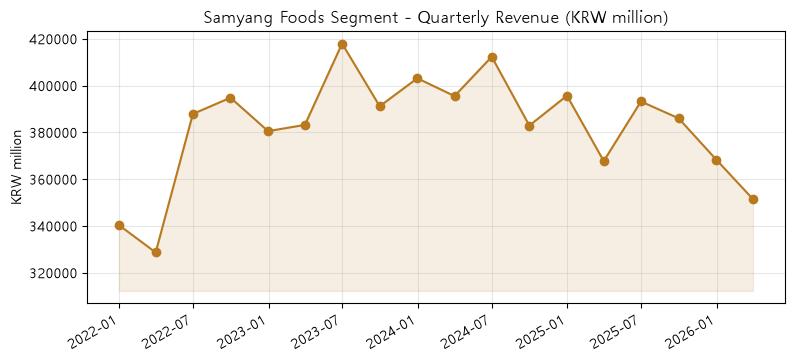

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(revenue_df.index, revenue_df["food_revenue"], marker="o", color="#B8791F")
ax.fill_between(revenue_df.index, revenue_df["food_revenue"], revenue_df["food_revenue"].min() * 0.95, alpha=0.12, color="#B8791F")
ax.set_title("Samyang Foods Segment - Quarterly Revenue (KRW million)")
ax.set_ylabel("KRW million")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 3. DB에서 경제지표 로드

`Food_Company_Sales/dashboard/backend`가 이미 수집해 둔 `indicator_points` 테이블에서
식품 원자재/수요 관련 지표만 가져온다.

In [7]:
from sqlalchemy import create_engine, text
import os

engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)

TARGETS = {
    "market_yfinance": ["옥수수", "대두", "대두유", "설탕(원당)", "커피", "밀",
                        "원달러환율", "WTI유가", "달러인덱스", "KOSPI", "구리(전기동)",
                        "브렌트유", "천연가스", "원유로환율", "미국국채10년"],
    "fao_food_price_index": ["Food Price Index", "Cereals", "Oils", "Sugar", "Dairy", "Meat"],
    "livestock_prices": ["한우", "돼지", "닭", "계란", "우유"],
    "rice_price": ["산지쌀가격(원/20kg)"],
    "price_index_kr_us": ["한국", "미국"],
    "retail_sales": ["백화점", "대형마트", "면세점"],
    "policy_rates": ["한국", "미국", "중국", "일본"],
}

with engine.connect() as conn:
    points = pd.read_sql(
        text("SELECT indicator_id, series_name, date, value FROM indicator_points "
             "WHERE indicator_id = ANY(:ids)"),
        conn,
        params={"ids": list(TARGETS.keys())},
        parse_dates=["date"],
    )

all_series = {}
for ind_id, names in TARGETS.items():
    for name in names:
        sub = points[(points.indicator_id == ind_id) & (points.series_name == name)]
        if sub.empty:
            continue
        all_series[f"{ind_id}::{name}"] = sub.set_index("date")["value"].sort_index()

print(f"{len(all_series)}개 지표 시계열 로드")

34개 지표 시계열 로드


## 4. 기간별 지표 평균과 매출 정렬

각 매출 구간(`period_from` ~ `period_to`)에 대해, 그 구간 안 지표 값의 평균을 계산한다.

In [8]:
rows = []
for pto, row in revenue_df.iterrows():
    pfrom = row["period_from"]
    rec = {"period_from": pfrom, "food_revenue": row["food_revenue"]}
    for key, ser in all_series.items():
        window = ser[(ser.index >= pd.Timestamp(pfrom)) & (ser.index <= pd.Timestamp(pto))]
        rec[key] = window.mean() if len(window) else None
    rows.append(rec)

aligned = pd.DataFrame(rows, index=revenue_df.index)
aligned.head()

,period_from,food_revenue,market_yfinance::옥수수,market_yfinance::대두,market_yfinance::대두유,market_yfinance::설탕(원당),market_yfinance::커피,market_yfinance::원달러환율,market_yfinance::WTI유가,market_yfinance::달러인덱스,...,rice_price::산지쌀가격(원/20kg),price_index_kr_us::한국,price_index_kr_us::미국,retail_sales::백화점,retail_sales::대형마트,retail_sales::면세점,policy_rates::한국,policy_rates::미국,policy_rates::중국,policy_rates::일본
period_to,,,,,,,,,,,,,,,,,,,,,
2021-12-31,2021-09-30,340363,566.400000,1252.915385,58.460154,19.510462,219.490769,1183.449558,77.071077,95.140000,...,52198.222222,103.753333,127.389433,145.833333,98.300000,122.866667,0.916667,0.125000,3.833333,-0.1
2022-03-31,2022-01-01,328648,673.149194,1561.588710,68.226613,18.621935,234.568548,1204.671721,95.009032,96.903387,...,48994.666667,105.456667,130.298327,129.266667,101.866667,109.700000,1.250000,0.208333,3.700000,-0.1
2022-06-30,2022-03-31,387848,777.234127,1682.119048,79.561111,19.246826,225.112698,1258.779848,108.391428,102.535397,...,45034.222222,107.513333,134.173180,141.033333,97.533333,110.900000,1.666667,0.958333,3.700000,-0.1
2022-09-30,2022-06-30,394797,659.373077,1530.230769,66.606923,18.204308,222.231538,1338.135079,91.652154,108.237077,...,40819.888889,108.726667,135.937107,132.200000,110.566667,118.266667,2.416667,2.625000,3.666667,-0.1
2022-12-31,2022-09-30,380507,668.359375,1431.519531,70.118594,19.227656,177.358594,1360.282278,82.595625,108.256094,...,45454.666667,109.163333,136.436213,148.500000,101.833333,120.700000,3.166667,3.791667,3.650000,-0.1


## 5. 레벨 기준 상관관계

구간 평균 지표값과 그 구간 식품 매출액을 그대로 비교한다.
장기 추세를 공유하는 지표끼리는 실제 연관이 없어도 상관계수가 높게 나올 수 있으니
(가짜 상관), 다음 절의 변화율 기준과 함께 봐야 한다.

In [9]:
def corr_table(df, value_col="food_revenue", min_n=6):
    out = []
    for key in all_series.keys():
        sub = df[[value_col, key]].dropna()
        if len(sub) < min_n or sub[key].std() == 0:
            continue
        out.append({
            "indicator": key,
            "pearson": sub[value_col].corr(sub[key]),
            "spearman": sub[value_col].corr(sub[key], method="spearman"),
            "n": len(sub),
        })
    return pd.DataFrame(out).sort_values("pearson", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


level_corr = corr_table(aligned)
level_corr.head(15)

,indicator,pearson,spearman,n
0,policy_rates::한국,0.739064,0.589225,18
1,policy_rates::미국,0.710067,0.676379,18
2,fao_food_price_index::Oils,-0.653461,-0.669763,18
3,market_yfinance::달러인덱스,0.606016,0.459236,18
4,market_yfinance::미국국채10년,0.595555,0.366357,18
5,fao_food_price_index::Sugar,0.534130,0.605779,18
6,market_yfinance::설탕(원당),0.512355,0.583075,18
7,market_yfinance::구리(전기동),-0.485324,-0.438596,18
8,rice_price::산지쌀가격(원/20kg),-0.451741,-0.366357,18
9,market_yfinance::KOSPI,-0.445758,-0.436533,18


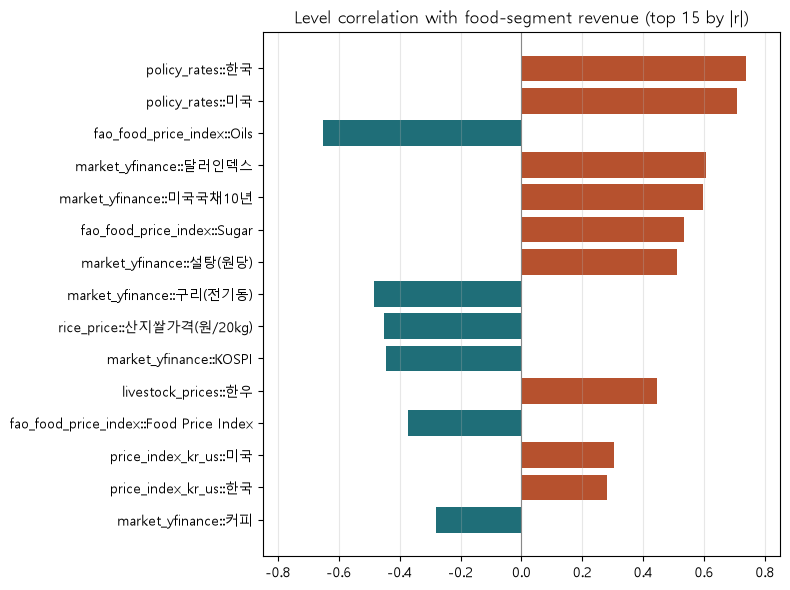

In [10]:
top = level_corr.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#B6512E" if v >= 0 else "#1F6E78" for v in top["pearson"]]
ax.barh(top["indicator"], top["pearson"], color=colors)
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_xlim(-0.85, 0.85)
ax.set_title("Level correlation with food-segment revenue (top 15 by |r|)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 전기 대비 변화율(%) 기준 상관관계

레벨 대신 구간 대비 변화율끼리 비교해서 장기 추세의 영향을 줄인다.

In [11]:
pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
pct_corr = corr_table(pct, min_n=6)
pct_corr.head(15)

,indicator,pearson,spearman,n
0,policy_rates::미국,0.626808,0.395815,17
1,fao_food_price_index::Meat,0.561219,0.519608,17
2,retail_sales::대형마트,-0.514656,-0.593137,17
3,price_index_kr_us::미국,0.507151,0.352941,17
4,market_yfinance::미국국채10년,0.439345,0.237745,17
5,fao_food_price_index::Sugar,0.420465,0.254902,17
6,retail_sales::백화점,0.393627,0.448529,17
7,policy_rates::일본,-0.376374,-0.513140,17
8,market_yfinance::설탕(원당),0.331864,0.186275,17
9,rice_price::산지쌀가격(원/20kg),-0.322338,-0.193627,17


## 7. 시차(Lag) 분석

지표가 t−L 구간 시점, 매출은 t 구간 시점일 때의 레벨 상관계수. 원자재 가격 변화가
몇 분기 뒤 매출에 반영되는지 보기 위함이다.

> **다중비교 주의**: 지표 수 × lag(0~3) 조합을 모두 훑어서 최댓값을 고르는 방식이라,
> 표본이 15~18개뿐인 상황에서는 우연히 강한 값이 나올 수 있다. 여기서 나온 결과는
> 확정된 관계가 아니라 **검증해볼 가설 후보**로 취급할 것.

In [12]:
level_df = aligned.drop(columns=["period_from"])
lag_rows = []
for key in all_series.keys():
    per_lag = {}
    for L in range(4):
        shifted = level_df[key].shift(L)
        sub = pd.concat([level_df["food_revenue"], shifted.rename("ind")], axis=1).dropna()
        if len(sub) < 6:
            continue
        per_lag[L] = sub["food_revenue"].corr(sub["ind"])
    if not per_lag:
        continue
    best_lag = max(per_lag, key=lambda L: abs(per_lag[L]))
    lag_rows.append({"indicator": key, "best_lag": best_lag, "best_corr": per_lag[best_lag], **{f"L{L}": per_lag.get(L) for L in range(4)}})

lag_df = pd.DataFrame(lag_rows).sort_values("best_corr", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
lag_df.head(15)

C:\Users\alswn\projects\RAG\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\alswn\projects\RAG\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,indicator,best_lag,best_corr,L0,L1,L2,L3
0,market_yfinance::구리(전기동),3,-0.780053,-0.485324,-0.443635,-0.608331,-0.780053
1,policy_rates::한국,0,0.739064,0.739064,0.600147,0.233430,0.114793
2,fao_food_price_index::Meat,2,-0.725515,-0.006748,-0.265521,-0.725515,-0.289350
3,policy_rates::미국,0,0.710067,0.710067,0.470248,0.050514,-0.030754
4,market_yfinance::커피,3,-0.697800,-0.280586,-0.413688,-0.640964,-0.697800
5,policy_rates::일본,3,-0.683307,-0.213422,-0.309384,-0.639387,-0.683307
6,livestock_prices::한우,1,0.667592,0.445710,0.667592,0.005964,-0.105224
7,fao_food_price_index::Oils,0,-0.653461,-0.653461,-0.383534,-0.261631,-0.175883
8,market_yfinance::KOSPI,2,-0.652740,-0.445758,-0.603690,-0.652740,-0.306970
9,market_yfinance::원유로환율,3,-0.636032,-0.074755,-0.267382,-0.569978,-0.636032


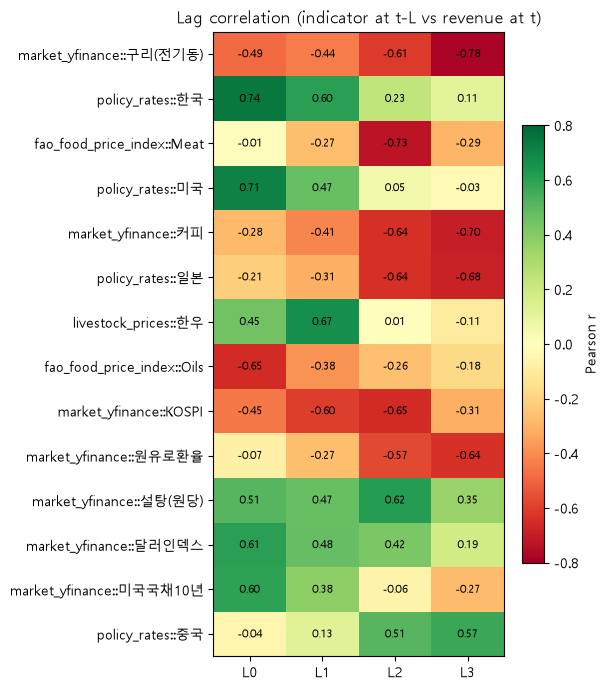

In [13]:
top_lag = lag_df.head(14).set_index("indicator")[["L0", "L1", "L2", "L3"]]
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(top_lag.values, cmap="RdYlGn", vmin=-0.8, vmax=0.8, aspect="auto")
ax.set_xticks(range(4), ["L0", "L1", "L2", "L3"])
ax.set_yticks(range(len(top_lag)), top_lag.index)
for i in range(top_lag.shape[0]):
    for j in range(top_lag.shape[1]):
        ax.text(j, i, f"{top_lag.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")
ax.set_title("Lag correlation (indicator at t-L vs revenue at t)")
plt.tight_layout()
plt.show()

## 결론 및 한계

- 가장 근거 있는 신호: **설탕 원자재 가격(yfinance 설탕 선물, FAO Sugar 지수) → 2개 분기 뒤 매출**의
  양(+)의 상관관계. 서로 독립된 두 소스에서 같은 방향·같은 시차로 재현됨.
- 나머지 상위 항목(정책금리, 구리, 환율 등)은 식품 매출과의 직접적 연결고리가 약해
  공통 거시 추세를 반영한 대리 상관일 가능성이 크다.
- 표본이 15~18개 분기로 작고, 2020년~2021년 상반기 공시 5건은 표 형식이 달라 파싱에서
  제외됐다. 표본을 늘리려면 이 구간의 파싱 로직을 보강해야 한다 (`FOOD_ROW_RE` 정규식이
  이 시기 문서의 표 레이아웃과 맞지 않음).
- lag 분석은 지표 수 × lag 조합을 모두 탐색해 최댓값을 고르는 방식이라 다중비교 문제가 있다.
  통계적으로 확정된 관계가 아니라 가설 후보로 취급할 것.